In [2]:
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt  
from sklearn.model_selection import train_test_split   
from sklearn.preprocessing import PolynomialFeatures   
from sklearn.linear_model import LinearRegression      
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error  

In [9]:
df = pd.read_csv('rounded_hours_student_scores.csv')  
df.head().values
#df.shape     

array([[ 1.1, 41. ],
       [ 1.2, 40. ],
       [ 1.4, 38. ],
       [ 1.5, 39. ],
       [ 1.6, 36. ]])

In [5]:
df = pd.read_csv('rounded_hours_student_scores.csv')  
df.head()   
#df.shape     

,Hours,Scores
0,1.1,41
1,1.2,40
2,1.4,38
3,1.5,39
4,1.6,36


In [10]:
X = df[['Hours']].values    
y = df['Scores'].values    

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 48
Test size: 12


In [13]:

model_simple = LinearRegression()


model_simple.fit(X_train, y_train)


y_pred_simple = model_simple.predict(X_test)

In [14]:
from sklearn.preprocessing import PolynomialFeatures

# Degree 2 ke polynomial features banane ka object
poly2 = PolynomialFeatures(degree=2, include_bias=False)

# Training aur test data ko transform karo
X_train_poly2 = poly2.fit_transform(X_train)   # ab isme [Hours, Hours^2]
X_test_poly2 = poly2.transform(X_test)

# Model train karo (Multiple Linear Regression)
model_poly2 = LinearRegression()
model_poly2.fit(X_train_poly2, y_train)

# Predict karo
y_pred_poly2 = model_poly2.predict(X_test_poly2)

In [15]:
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

model_poly3 = LinearRegression()
model_poly3.fit(X_train_poly3, y_train)
y_pred_poly3 = model_poly3.predict(X_test_poly3)

In [16]:
def evaluate(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{model_name:25} R²={r2:.4f}  MSE={mse:.2f}  RMSE={rmse:.2f}  MAE={mae:.2f}")
    return r2, mse, rmse, mae

print("\n--- Test Set Performance ---")
evaluate(y_test, y_pred_simple, "Simple Linear (deg1)")
evaluate(y_test, y_pred_poly2, "Multiple Linear (deg2)")
evaluate(y_test, y_pred_poly3, "Multiple Linear (deg3)")


--- Test Set Performance ---
Simple Linear (deg1)      R²=0.5810  MSE=15.67  RMSE=3.96  MAE=2.82
Multiple Linear (deg2)    R²=0.5953  MSE=15.13  RMSE=3.89  MAE=2.69
Multiple Linear (deg3)    R²=0.5503  MSE=16.81  RMSE=4.10  MAE=2.90


(0.5502833175303905,
 16.814407072335953,
 np.float64(4.100537412624832),
 2.900672613065359)

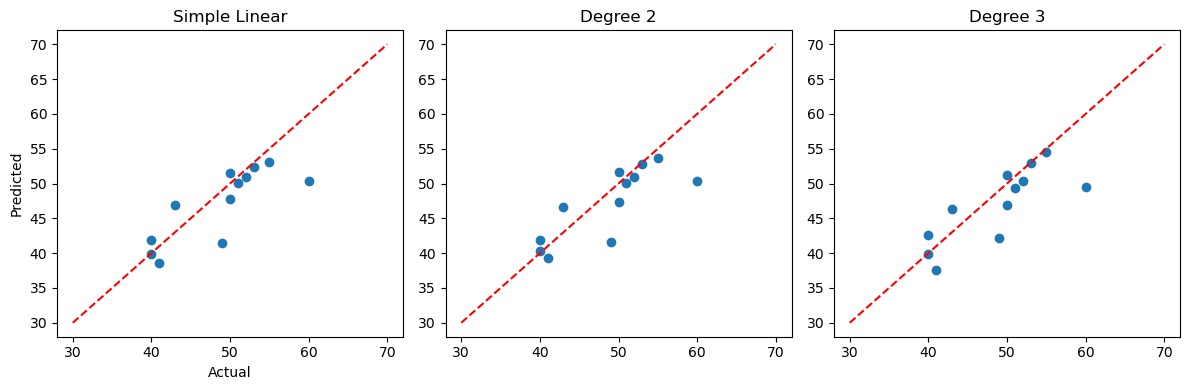

In [17]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_simple)
plt.plot([30,70], [30,70], 'r--')   # perfect line
plt.title("Simple Linear")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_poly2)
plt.plot([30,70], [30,70], 'r--')
plt.title("Degree 2")

plt.subplot(1,3,3)
plt.scatter(y_test, y_pred_poly3)
plt.plot([30,70], [30,70], 'r--')
plt.title("Degree 3")

plt.tight_layout()
plt.show()

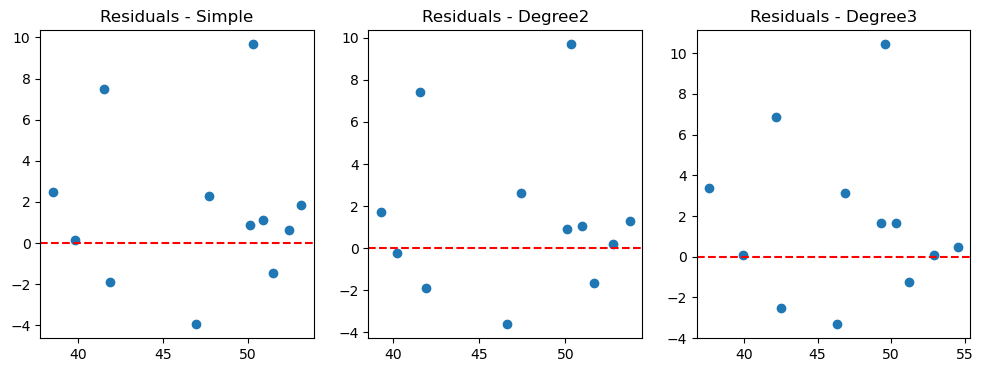

In [19]:
residuals_simple = y_test - y_pred_simple
residuals_poly2 = y_test - y_pred_poly2
residuals_poly3 = y_test - y_pred_poly3

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.scatter(y_pred_simple, residuals_simple)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residuals - Simple")

plt.subplot(1,3,2)
plt.scatter(y_pred_poly2, residuals_poly2)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residuals - Degree2")

plt.subplot(1,3,3)
plt.scatter(y_pred_poly3, residuals_poly3)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residuals - Degree3")
plt.show()